# Exploratory Data Analysis — E-commerce Fraud Data

## Overview
This notebook performs exploratory data analysis (EDA) on the `Fraud_Data.csv` dataset,
which contains e-commerce transactions labeled as fraudulent or legitimate.

## Objectives
- Understand the structure and quality of the data
- Identify and handle missing values and duplicates
- Correct data types (especially timestamp columns)
- Visualize the class imbalance between fraud and legitimate transactions
- Explore how numerical and categorical features relate to fraud

## Dataset
- **Source:** Fraud_Data.csv (e-commerce transactions)
- **Target variable:** `class` — 1 = Fraud, 0 = Legitimate
- **Key features:** user_id, signup_time, purchase_time, purchase_value, device_id,
  source, browser, sex, age, ip_address

## Author
- **Name:** Tsion Habtesilassei
- **Project:** Adey Innovations — Fraud Detection System
- **Date:** June 2026

## 1. Import Libraries

We import all necessary Python libraries for data manipulation and visualization:
- `pandas` — for loading and manipulating tabular data
- `numpy` — for numerical operations
- `matplotlib` and `seaborn` — for creating visualizations
- `warnings` — to suppress non-critical warnings that clutter the output

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Dataset

We load `Fraud_Data.csv` from the `data/raw/` directory.
After loading, we inspect:
- The shape (rows × columns)
- The first few rows to understand the structure
- Column names and their data types

In [4]:
df = pd.read_csv('../data/raw/Fraud_Data.csv')

print("Dataset shape:", df.shape)
print(f"\nRows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print("\nColumn names:", df.columns.tolist())
df.head()

Dataset shape: (151112, 11)

Rows: 151,112 | Columns: 11

Column names: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class']


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


## 3. Data Quality Check

Now that the data is loaded successfully, we inspect its quality before any analysis.

**What we found from loading:**
- Dataset contains **151,112 transactions** across **11 columns**
- Features include user behavior (age, sex), device info (device_id, browser),
  traffic source, timestamps (signup_time, purchase_time), and IP address
- The target column `class` indicates fraud (1) or legitimate (0)

**In this section we check:**
- **Data types** — `signup_time` and `purchase_time` are currently strings, not datetime
- **Missing values** — which columns have nulls and how many
- **Descriptive statistics** — min, max, mean for numeric columns to spot anomalies

These findings will directly guide our preprocessing decisions.

In [5]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df)
if missing_df['Missing Count'].sum() == 0:
    print("\nNo missing values found — data is complete.")

print("\n=== DESCRIPTIVE STATISTICS ===")
df.describe()

=== DATA TYPES ===
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

=== MISSING VALUES ===
                Missing Count  Missing %
user_id                     0        0.0
signup_time                 0        0.0
purchase_time               0        0.0
purchase_value              0        0.0
device_id                   0        0.0
source                      0        0.0
browser                     0        0.0
sex                         0        0.0
age                         0        0.0
ip_address                  0        0.0
class                       0        0.0

No missing values found — data is complete.

=== DESCRIPTIVE STATISTICS ===


,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


## 4. Data Quality Findings & Observations

From the quality check above, we found the following:

**Data Types:**
- `signup_time` and `purchase_time` are stored as `str` (string) — must be converted 
  to `datetime` for time-based feature engineering
- `ip_address` is stored as `float64` — this is correct for range-based country lookup
- All other types look appropriate

**Missing Values:**
- No missing values found across all 11 columns — the dataset is complete
- No imputation needed

**Descriptive Statistics — Key Observations:**
- `purchase_value` ranges from $9 to $154 — reasonable e-commerce range
- `age` ranges from 18 to 76 — no underage users, but max of 76 is plausible
- `ip_address` stored as large float numbers (up to 4.29 billion) — this is the 
  integer representation of IPv4 addresses, which is exactly what we need for 
  the IP-to-country range lookup
- `class` mean of 0.094 confirms roughly **9.4% fraud rate** — highly imbalanced

**Action Items:**
- Convert `signup_time` and `purchase_time` from string to datetime ✓ (next cell)
- No missing value handling needed ✓
- No column drops needed ✓

## 5. Fix Data Types — Convert Timestamps to Datetime

`signup_time` and `purchase_time` are currently plain text strings like 
`"2015-02-24 22:55:49"`. We convert them to proper `datetime` objects using pandas.

**Why this matters:**
- Without datetime format, we cannot subtract two timestamps
- We need this for `time_since_signup` — a key fraud signal
  (fraudsters often purchase within seconds/minutes of signing up)
- We also need it to extract `hour_of_day` and `day_of_week`

In [6]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

print("=== DATA TYPES AFTER CONVERSION ===")
print(df[['signup_time', 'purchase_time']].dtypes)

print("\n=== SAMPLE VALUES ===")
print(df[['signup_time', 'purchase_time']].head())

print("\n=== DATE RANGES ===")
print(f"Signup time  — min: {df['signup_time'].min()} | max: {df['signup_time'].max()}")
print(f"Purchase time — min: {df['purchase_time'].min()} | max: {df['purchase_time'].max()}")

=== DATA TYPES AFTER CONVERSION ===
signup_time      datetime64[us]
purchase_time    datetime64[us]
dtype: object

=== SAMPLE VALUES ===
          signup_time       purchase_time
0 2015-02-24 22:55:49 2015-04-18 02:47:11
1 2015-06-07 20:39:50 2015-06-08 01:38:54
2 2015-01-01 18:52:44 2015-01-01 18:52:45
3 2015-04-28 21:13:25 2015-05-04 13:54:50
4 2015-07-21 07:09:52 2015-09-09 18:40:53

=== DATE RANGES ===
Signup time  — min: 2015-01-01 00:00:42 | max: 2015-08-18 04:40:29
Purchase time — min: 2015-01-01 00:00:44 | max: 2015-12-16 02:56:05


## 6. Remove Duplicates

Duplicate rows can distort model training by giving certain transactions 
more influence than they deserve. We check for exact duplicate rows across 
all columns and remove them if found.

**Why this matters:**
- Duplicates artificially inflate the training set
- They can cause data leakage if the same row ends up in both train and test sets
- Removing them ensures each transaction is counted only once

In [7]:
print(f"Shape BEFORE removing duplicates: {df.shape}")

exact_dups = df.duplicated().sum()
print(f"Exact duplicate rows found: {exact_dups}")

df = df.drop_duplicates()
print(f"Shape AFTER removing duplicates: {df.shape}")

if exact_dups == 0:
    print("\nNo duplicates found — dataset is clean.")
else:
    print(f"\nRemoved {exact_dups} duplicate rows.")

Shape BEFORE removing duplicates: (151112, 11)
Exact duplicate rows found: 0
Shape AFTER removing duplicates: (151112, 11)

No duplicates found — dataset is clean.


## 7. Class Imbalance Analysis

**This is the most critical finding for our modeling strategy.**

From the descriptive statistics we already know the `class` mean is 0.094, 
meaning approximately **9.4% of transactions are fraudulent**.

**Why class imbalance is a serious problem:**
- A model that predicts "legitimate" for EVERY transaction would achieve 
  90.6% accuracy — but catch ZERO fraud cases
- This means **accuracy is a misleading metric** for this problem
- We must use **AUC-PR (Precision-Recall)** and **F1-score** instead
- We will apply **SMOTE** (Synthetic Minority Oversampling Technique) 
  on the training set to balance the classes before model training

We visualize the imbalance below with a count plot and pie chart.

=== CLASS DISTRIBUTION ===
Legitimate (0): 136,961  (90.64%)
Fraud     (1): 14,151  (9.36%)
Imbalance ratio: 9.7:1

For every 1 fraud case there are 10 legitimate transactions


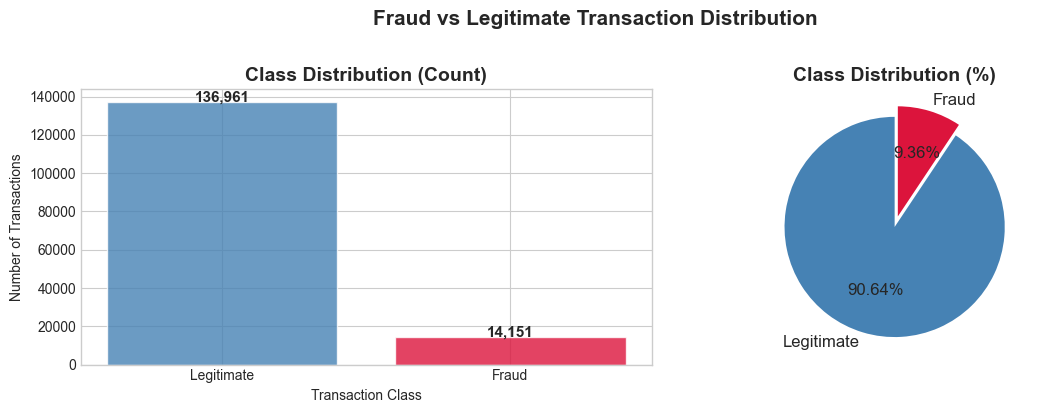

Plot saved to data/processed/


In [8]:
class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

print("=== CLASS DISTRIBUTION ===")
print(f"Legitimate (0): {class_counts[0]:,}  ({class_pct[0]:.2f}%)")
print(f"Fraud     (1): {class_counts[1]:,}  ({class_pct[1]:.2f}%)")
print(f"Imbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1")
print(f"\nFor every 1 fraud case there are {class_counts[0]/class_counts[1]:.0f} legitimate transactions")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['steelblue', 'crimson'], alpha=0.8, edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xlabel('Transaction Class')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

axes[1].pie(class_counts.values,
            labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'crimson'],
            autopct='%1.2f%%',
            startangle=90,
            explode=(0, 0.1),
            textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Fraud vs Legitimate Transaction Distribution', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/class_distribution_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/processed/")


### Interpretation — Class Distribution

The dataset contains **136,961 legitimate transactions (90.64%)** and 
**14,151 fraudulent transactions (9.36%)**, giving an imbalance ratio of approximately **9.7:1**.

**Key takeaways:**
- The dataset is severely imbalanced — fraud is the minority class
- A naive model predicting "legitimate" for every transaction would achieve 
  90.64% accuracy while catching zero fraud cases
- This confirms that **accuracy is not a suitable metric** for this problem
- We will use **AUC-PR (Precision-Recall AUC)** and **F1-score** as primary metrics
- We will apply **SMOTE** on the training set only to synthetically balance the classes
  before model training

## 8. Univariate Analysis — Numerical Features

We examine the distribution of each numerical feature split by class 
(fraud vs legitimate) to identify which features carry predictive signal.

**Features examined:**
- `purchase_value` — amount spent per transaction in dollars
- `age` — age of the user making the purchase

**What we look for:**
- If distributions overlap heavily → feature has weak predictive power alone
- If distributions are clearly separated → feature is a strong fraud signal

We use overlapping histograms (density-normalized) so both classes 
are visually comparable despite the imbalance.

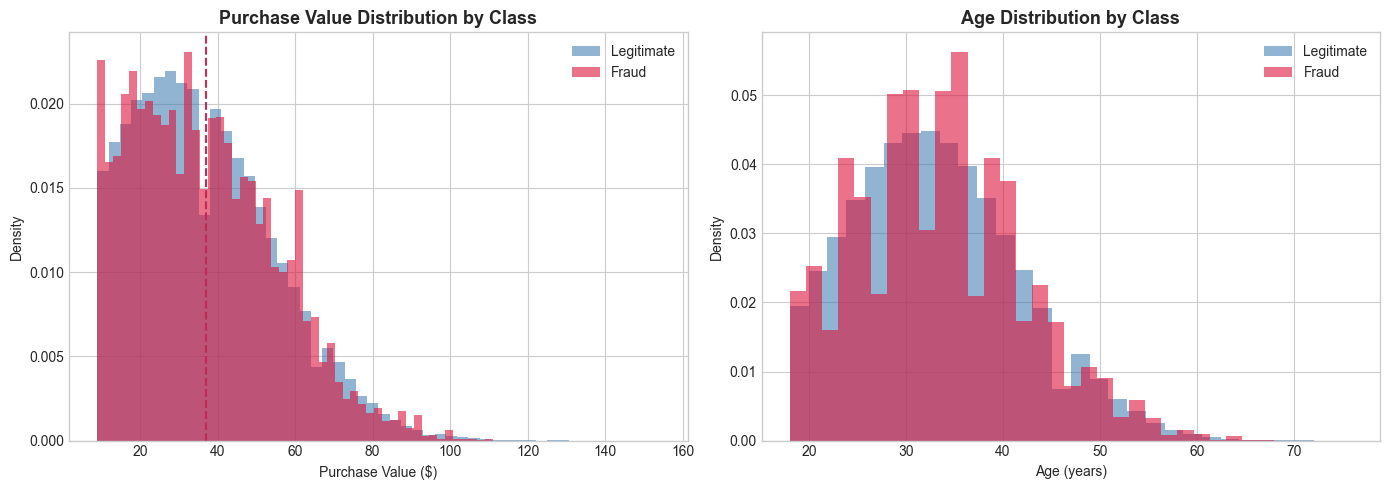

=== MEAN COMPARISON BY CLASS ===
Purchase Value — Legitimate: $36.93 | Fraud: $36.99
Age            — Legitimate: 33.1 yrs  | Fraud: 33.3 yrs


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Purchase value
axes[0].hist(df[df['class']==0]['purchase_value'], bins=50,
             alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[0].hist(df[df['class']==1]['purchase_value'], bins=50,
             alpha=0.6, color='crimson', label='Fraud', density=True)
axes[0].set_title('Purchase Value Distribution by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Purchase Value ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(df[df['class']==0]['purchase_value'].mean(), 
                color='steelblue', linestyle='--', alpha=0.8, label='Legit mean')
axes[0].axvline(df[df['class']==1]['purchase_value'].mean(), 
                color='crimson', linestyle='--', alpha=0.8, label='Fraud mean')

# Age
axes[1].hist(df[df['class']==0]['age'], bins=30,
             alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[1].hist(df[df['class']==1]['age'], bins=30,
             alpha=0.6, color='crimson', label='Fraud', density=True)
axes[1].set_title('Age Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print mean comparison
print("=== MEAN COMPARISON BY CLASS ===")
print(f"Purchase Value — Legitimate: ${df[df['class']==0]['purchase_value'].mean():.2f} | Fraud: ${df[df['class']==1]['purchase_value'].mean():.2f}")
print(f"Age            — Legitimate: {df[df['class']==0]['age'].mean():.1f} yrs  | Fraud: {df[df['class']==1]['age'].mean():.1f} yrs")

### Interpretation — Numerical Feature Distributions

**Purchase Value:**
- Both fraud and legitimate transactions show a **right-skewed distribution** — 
  most transactions cluster at lower values ($10–$60)
- The fraud mean (~$36) is slightly lower than the legitimate mean, 
  suggesting fraudsters tend to make smaller purchases to avoid detection
- The distributions overlap heavily, meaning purchase value alone 
  is not enough to separate fraud from legitimate transactions
- This feature will be more useful in combination with other features

**Age:**
- Both classes follow a similar distribution peaking around ages 25–40
- The distributions are nearly identical, suggesting age alone 
  is not a strong fraud predictor
- However, age combined with behavioral features (time since signup, 
  transaction velocity) may still contribute to model performance
- We will let the model decide the importance of age through feature importance analysis

## 9. Bivariate Analysis — Categorical Features vs Fraud Rate

We compute the **fraud rate** for each category in our categorical features.
Fraud rate = (number of fraud transactions in category) / (total transactions in category).

**Features examined:**
- `source` — traffic channel (SEO, Ads, Direct)
- `browser` — browser used (Chrome, Firefox, Safari, Opera, IE)
- `sex` — gender of the user (M/F)
- `age_group` — age bucketed into ranges for easier comparison

**What we look for:**
- Categories with noticeably higher fraud rates are strong candidate features
- These patterns will inform our feature engineering and business recommendations

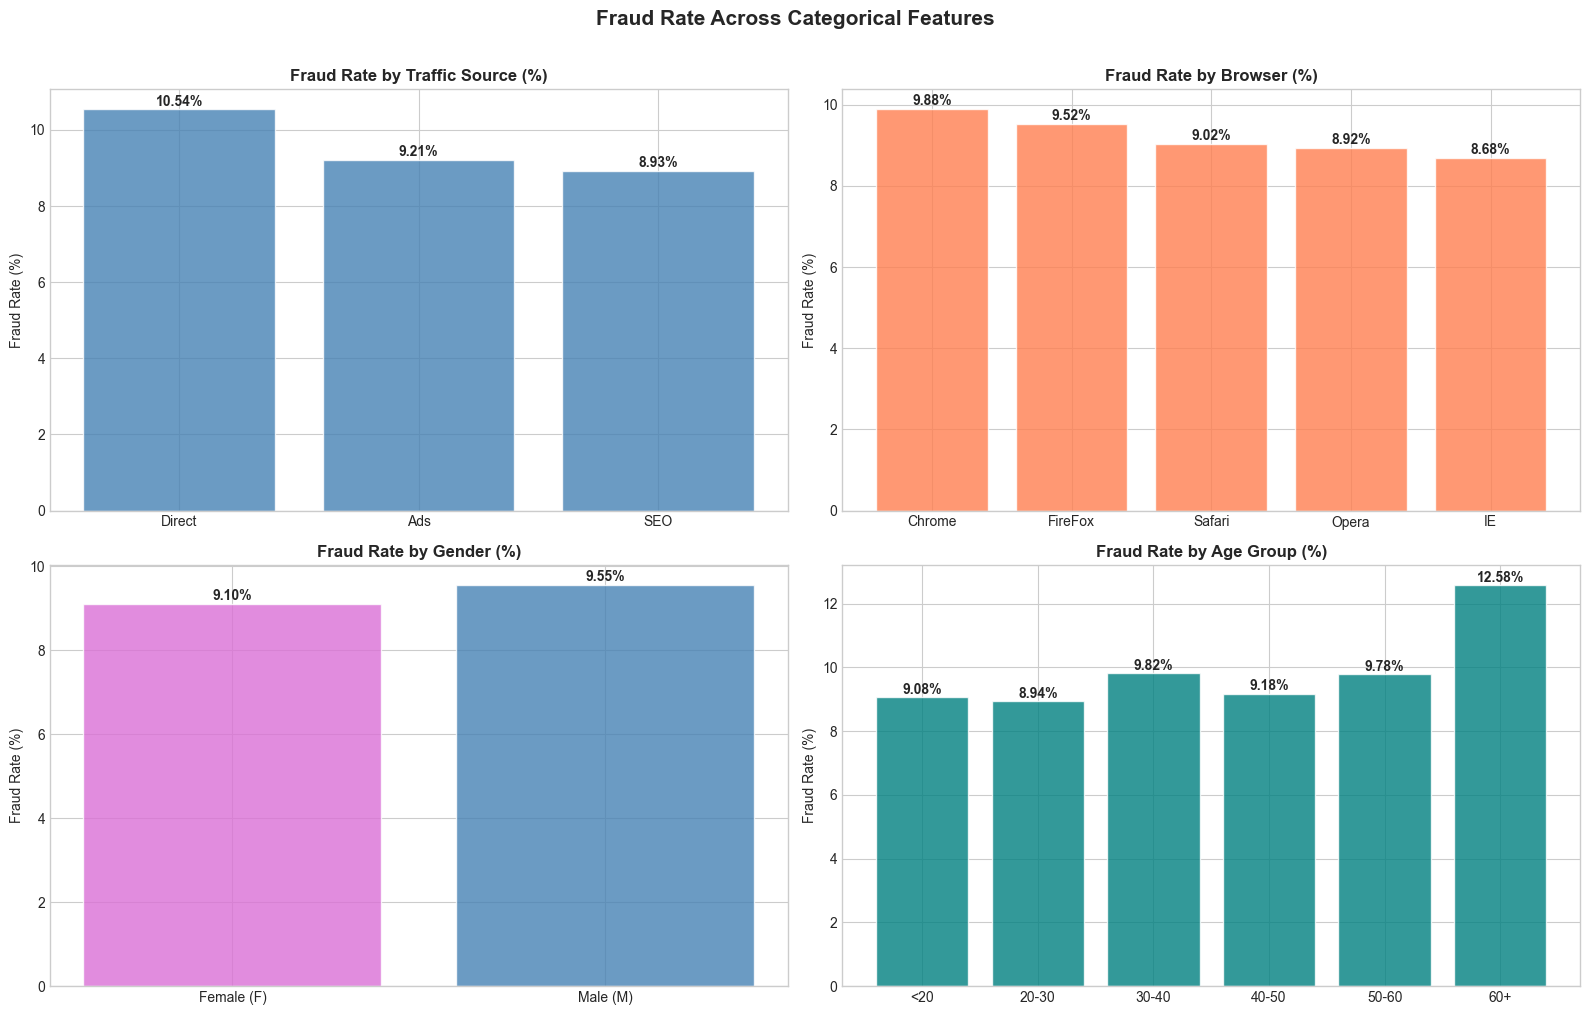

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Fraud rate by source
fraud_by_source = df.groupby('source')['class'].mean().sort_values(ascending=False)
bars = axes[0,0].bar(fraud_by_source.index, fraud_by_source.values * 100,
                     color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Fraud Rate by Traffic Source (%)', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('Fraud Rate (%)')
for bar, v in zip(bars, fraud_by_source.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, v*100 + 0.1,
                   f'{v*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Fraud rate by browser
fraud_by_browser = df.groupby('browser')['class'].mean().sort_values(ascending=False)
bars = axes[0,1].bar(fraud_by_browser.index, fraud_by_browser.values * 100,
                     color='coral', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Fraud Rate by Browser (%)', fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('Fraud Rate (%)')
for bar, v in zip(bars, fraud_by_browser.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v*100 + 0.1,
                   f'{v*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Fraud rate by sex
fraud_by_sex = df.groupby('sex')['class'].mean()
bars = axes[1,0].bar(['Female (F)', 'Male (M)'], fraud_by_sex.values * 100,
                     color=['orchid', 'steelblue'], alpha=0.8, edgecolor='white')
axes[1,0].set_title('Fraud Rate by Gender (%)', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Fraud Rate (%)')
for bar, v in zip(bars, fraud_by_sex.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, v*100 + 0.1,
                   f'{v*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Fraud rate by age group
df['age_group'] = pd.cut(df['age'], bins=[0,20,30,40,50,60,100],
                          labels=['<20','20-30','30-40','40-50','50-60','60+'])
fraud_by_age = df.groupby('age_group', observed=True)['class'].mean()
bars = axes[1,1].bar(fraud_by_age.index.astype(str), fraud_by_age.values * 100,
                     color='teal', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Fraud Rate by Age Group (%)', fontweight='bold', fontsize=12)
axes[1,1].set_ylabel('Fraud Rate (%)')
for bar, v in zip(bars, fraud_by_age.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, v*100 + 0.1,
                   f'{v*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Fraud Rate Across Categorical Features', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/categorical_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Categorical Feature Fraud Rates

**Traffic Source:**
- Direct traffic has the highest fraud rate at **10.54%**
- Ads traffic is in the middle at **9.21%**
- SEO traffic has the lowest fraud rate at **8.93%**
- Users arriving directly (typing the URL) are slightly more suspicious — 
  this may indicate fraudsters who already know the target site

**Browser:**
- Chrome users have the highest fraud rate at **9.88%**
- IE users have the lowest at **8.68%**
- The differences are relatively small (~1.2% spread) suggesting browser 
  alone is not a strong discriminator, but may contribute marginally

**Gender:**
- Male users have a slightly higher fraud rate (**9.55%**) than female (**9.10%**)
- The difference is small (~0.45%) — gender is unlikely to be a strong feature alone

**Age Group:**
- The **60+ age group has the highest fraud rate at 12.58%** — notably higher 
  than all other groups
- The 20-30 group has the lowest at **8.94%**
- Older users being targeted more frequently aligns with known fraud patterns 
  where elderly users are more vulnerable to social engineering attacks
- This is a meaningful signal and `age` will be retained as a feature

## 10. Save Cleaned Data

We save the cleaned and type-corrected dataset to `data/processed/` so it can 
be loaded directly in the next notebook without repeating any preprocessing steps.

**What was cleaned:**
- Timestamps converted from string to datetime
- Duplicates checked and removed
- Temporary `age_group` column dropped (only needed for visualization)

The saved file `fraud_data_cleaned.csv` will be the input for the 
**feature engineering notebook** where we create fraud-specific features.

In [11]:
df = df.drop(columns=['age_group'])
df.to_csv('../data/processed/fraud_data_cleaned.csv', index=False)

print(f"Saved: data/processed/fraud_data_cleaned.csv")
print(f"Final shape: {df.shape}")

Saved: data/processed/fraud_data_cleaned.csv
Final shape: (151112, 11)
